# 1. Clustering Models

## 1.1 Objective

The previous stages established the analytical representation used for clustering:

- 1,433 respondents;
- 495 finite numerical features after preparation;
- 391 features retained after variance and redundancy filtering;
- standardized selected features for distance-based analysis;
- 234 PCA components retaining 90% cumulative variance;
- MDS retained as a complementary two-dimensional representation.

The purpose of this notebook is to investigate whether the prepared response space contains meaningful grouping structure.

Four complementary clustering approaches are examined:

1. K-Means;
2. Gaussian Mixture
3. Agglomerative hierarchical clustering;
4. DBSCAN.

The models are deliberately different because they make different assumptions about what a cluster looks like.

The analysis therefore follows:

**question → representation → model assumption → diagnostic evidence → dedicated interpretation → decision**

The objective is not to force the respondents into a predetermined number of groups. The objective is to determine whether the data provide sufficient evidence for coherent, interpretable clustering structures.

## 1.2 Modeling Questions

The clustering stage addresses five questions:

1. Does the selected standardized feature space contain a useful partitioning structure?
2. Does PCA provide a more practical representation without materially weakening the clustering structure?
3. Do probabilistic clusters provide information that hard K-Means assignments cannot provide?
4. Does hierarchical clustering reveal a coherent multilevel structure?
5. Does the dataset contain density-separated groups that justify DBSCAN?

The four methods are therefore not treated as interchangeable algorithms.

**K-Means** provides the baseline because it it a direct distance-based method for compact clusters.

**GMM** tests whether observations are better represented through probability distributions and soft membership.

**Hierarchical Clustering** provides a different view by exposing how groups merge across increasing dissimilarity levels.

**DBSCAN** tests whether dense regions and noise provide a more appropriate description of the respondent population.

No single metric is treated as sufficient evidence for a final clustering decision.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.cluster.hierarchy import linkage
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
from sklearn.mixture import GaussianMixture

from mental_health_ml.evaluation import (
    calinski_harabasz_index,
    cophenetic_correlation,
    cluster_size_table,
    estimate_knee_from_k_distance,
    evaluate_clustering,
    k_distance_profile,
    silhouette_profile,
    summarize_experiment,
)
from mental_health_ml.visualization import (
    plot_cluster_projection,
    plot_dendrogram,
    plot_metric_curve,
    plot_silhouette_profile,
)

# Keep stochastic model initialization reproducible.
RANDOM_STATE = 42

# Restrict the search to a controlled, interpretable range of cluster counts.
K_RANGE = range(2, 9)
GMM_COMPONENT_RANGE = range(2, 9)

DATA_PATH = Path("../data/processed")

sns.set_theme(
    context="notebook",
    style="whitegrid",
)

# 2. Representation Control

## 2.1 Persisted Analytical Representations

The clustering notebook uses the persisted representations produced by the previous analytical stage rather than rebuilding preprocessing.

This is because clustering results should reflect the established analytical representation rather than hidden transformations performed inside the modeling notebook.

Three persisted representations are inspected before modelling:

- selected standardized features;
- PCA components;
- MDS coordinates.

## 2.2 Selected Standardized Representation

The 391 selected variables retain the original feature meanings and therefore provide the most direct baseline for distance-based clustering.

## 2.3 PCA Representation

The 234 PCA components retain 90% cumulative variance while reducing the feature-space dimensionality.

PCA is not assumed to be superior simply because it reduces dimensionality. Its value must be demonstrated through the resulting clustering behaviour.

## 2.4 MDS Representation

MDS is not used as the primary clustering representation because the persisted MDS representation contains only two dimensions and was generated primarily as a complementary distance-based visualization. Using it as the main clustering space would discard substantially more information than the PCA representation.

## 2.5 Representation Integrity

The respondent ordering must remain identical across all persisted representations.

In [2]:
# Load the representations produced by the preceding analytical stage.
X_selected_scaled = pd.read_csv(
    DATA_PATH / "mental_health_selected_scaled.csv"
)

X_pca = pd.read_csv(
    DATA_PATH / "mental_health_pca.csv"
)

X_mds = pd.read_csv(
    DATA_PATH / "mental_health_mds.csv"
)

# Validate observation counts before fitting any clustering model.
if not (
    len(X_selected_scaled)
    == len(X_pca)
    == len(X_mds)
    == 1433
):
    raise ValueError(
        "All persisted representations must contain 1,433 observations."
    )

# Validate the numerical representations before distance-based modelling.
for name, data in {
    "selected standardized": X_selected_scaled,
    "PCA": X_pca,
    "MDS": X_mds,
}.items():
    if data.isna().any().any():
        raise ValueError(
            f"The {name} representation contains missing values."
        )

    if not np.isfinite(data.to_numpy()).all():
        raise ValueError(
            f"The {name} representation contains non-finite values."
        )

# Confirm that all persisted representations preserve respondent ordering.
if not (
    X_selected_scaled.index.equals(X_pca.index)
    and X_selected_scaled.index.equals(X_mds.index)
):
    raise ValueError(
        "The persisted representations are not aligned by respondent."
    )

display(
    pd.DataFrame(
        {
            "representation": [
                "Selected standardized features",
                "PCA",
                "MDS",
            ],
            "observations": [
                X_selected_scaled.shape[0],
                X_pca.shape[0],
                X_mds.shape[0],
            ],
            "features": [
                X_selected_scaled.shape[1],
                X_pca.shape[1],
                X_mds.shape[1],
            ],
        }
    )
)

,representation,observations,features
0,Selected standardized features,1433,391
1,PCA,1433,234
2,MDS,1433,2


### 2.5.1 Interpretation of the Representation-Control Output

The output confirms that the three persisted representations contain the same 1,433 respondents while differing in dimensionality. The selected standardised representation contains 391 variables, PCA contains 234 components, and MDS contains two coordinates.

This is important for experimental validity: subsequent differences in clustering behaviour can be attributed to the representation and model choices rather than to different respondent populations.

## 2.6 Representation Decision

The selected standardised representation is retained for E01 because it provides the most direct baseline: the clustering algorithm operates on the selected original variables after standardisation.

PCA is then used for the remaining model families because the selected representation still contains 391 dimensions.

This distinction matters. Feature selection removes redundant original variables. PCA creates a new orthogonal representation of the retained variables.

The experiment therefore tests whether a more compact representation changes the apparent clustering structure rather than assuming that dimensionality reduction automatically improves clustering.

The model comparison will distinguish between:

- changes caused by the clustering algorithm; and
- changes caused by the feature representation.

### 2.6.1 Interpretation of the Representation-Control Output

The representation-control table is a reproducibility check rather than a clustering result. It confirms that all persisted representations contain the same 1,433 respondents while differing in feature dimensionality. The selected standardised representation contains 391 variables, PCA contains 234 components, and MDS contains two coordinates.

This confirms that the subsequent experiments can compare clustering behaviour without changing the underlying respondent set.

# 3. E01 — K-Means on Selected Standardised Features

## 3.1 Question

Does the selected standardised feature space contain a partitioning structure that can be represented by compact, hard clusters?

## 3.2 Why K-Means?

K-Means is used as the baseline because it directly measures distance from observations to cluster centroids. Its objective is to minimise the within-cluster sum of squared errors.

K-Means requires the number of clusters to be specified, produces hard assignments, and favours compact cluster structures. These characteristics make it an appropriate baseline while also motivating the subsequent GMM, hierarchical, and DBSCAN experiments.

## 3.3 Choosing the Candidate Number of Clusters

Values of K=2 through K=8 are examined. Inertia, silhouette, and the complementary Calinski-Harabasz diagnostic are considered without reducing them to a single composite score.

In [3]:
kmeans_selected_results = []
kmeans_selected_models = {}

# Evaluate a controlled range of k values using repeated initialization.
for k in K_RANGE:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(X_selected_scaled)

    evaluation = evaluate_clustering(
        X_selected_scaled,
        labels,
        inertia=model.inertia_,
    )

    kmeans_selected_models[k] = model

    kmeans_selected_results.append(
        {
            "k": k,
            "inertia": evaluation["inertia"],
            "silhouette": evaluation["silhouette"],
            "calinski_harabasz": calinski_harabasz_index(
                X_selected_scaled,
                labels,
            ),
        }
    )

kmeans_selected_results = pd.DataFrame(
    kmeans_selected_results
)

display(kmeans_selected_results.round(4))

,k,inertia,silhouette,calinski_harabasz
0,2,541703.7211,0.0959,49.1331
1,3,533068.2337,0.0142,36.5298
2,4,526871.7281,0.0186,30.2245
3,5,524910.5858,0.0042,24.0709
4,6,519034.9836,0.0068,22.6919
5,7,515519.8333,0.0006,20.6461
6,8,513465.4864,0.0013,18.5695


### 3.3.1 Interpretation of the K-Means Results Table

The K-Means results table shows a large drop in silhouette from K=2 to K=3, followed by values close to zero across the remaining tested cluster counts. Inertia decreases progressively as K increases. The table therefore indicates that K=2 is the strongest tested candidate while also showing that the overall separation remains weak.

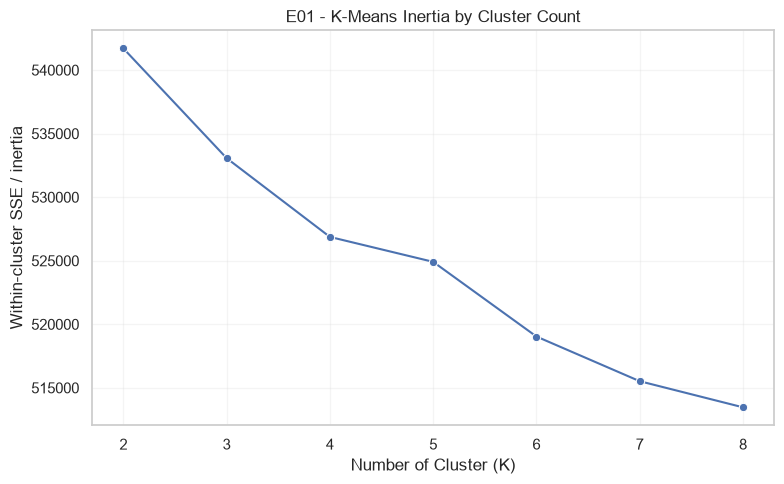

In [4]:
# The elbow plot examines how quickly additional clusters reduce SSE.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_selected_results,
    x="k",
    y="inertia",
    ax=ax,
    title="E01 - K-Means Inertia by Cluster Count",
    xlabel="Number of Cluster (K)",
    ylabel="Within-cluster SSE / inertia",
)

fig.tight_layout()
plt.show()

### 3.3.2 Interpretation of the K-Means Inertia/Elbow Figure

The inertia curve decreases as K increases, as expected, because additional centroids reduce within-cluster squared error. The curve does not display an exceptionally sharp elbow, so inertia alone does not identify a uniquely compelling cluster count. The result therefore remains a diagnostic of diminishing returns rather than a standalone selection rule.

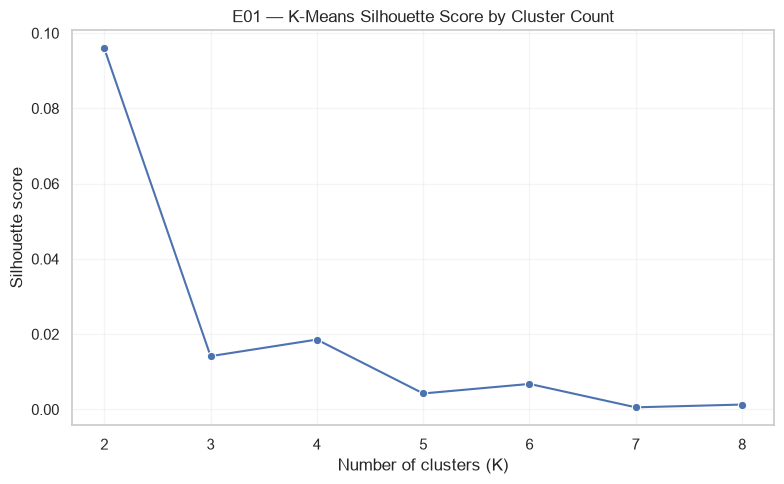

In [5]:
# The silhoutte curve evaluates cohesion and separation across the same
# candidate K values used for the inertia analysis.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_selected_results,
    x="k",
    y="silhouette",
    ax=ax,
    title="E01 — K-Means Silhouette Score by Cluster Count",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

### 3.3.3 Interpretation of the K-Means Silhouette Curve

The silhouette curve reaches its strongest value at K=2 and drops sharply for K≥3. The values after K=2 remain close to zero, indicating that increasing the number of clusters does not create substantially better-separated groups. K=2 is therefore the strongest tested K-Means candidate on geometric cohesion and separation, although the absolute separation remains weak.

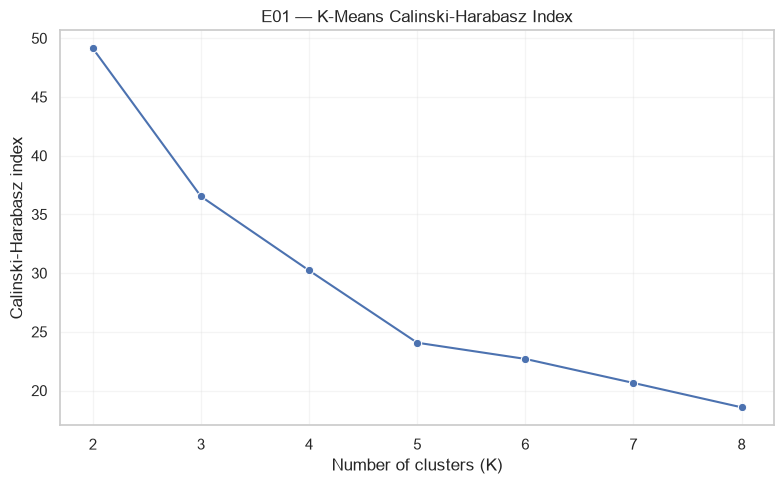

In [6]:
# The Calinski-Harabasz curve provides a complementary dispersion-based
# diagnostic for the same K-Means candidate range.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_selected_results,
    x="k",
    y="calinski_harabasz",
    ax=ax,
    title="E01 — K-Means Calinski-Harabasz Index",
    xlabel="Number of clusters (K)",
    ylabel="Calinski-Harabasz index",
)

fig.tight_layout()
plt.show()

### 3.3.4 Interpretation of the K-Means Calinski-Harabasz Diagnostic

The Calinski-Harabasz output is interpreted by identifying where the index is highest across the tested K values. A preference for the same K selected by silhouette would provide independent support from a dispersion-based criterion; a different preference would show that the apparent structure depends on the evaluation criterion. This diagnostic is therefore retained as complementary evidence rather than as a replacement for silhouette or the elbow analysis.

In [8]:
# Identify the strongest silhouette candidate for downstream inspection.
if kmeans_selected_results["silhouette"].notna().sum() == 0:
    raise ValueError(
        "No valid K-Means silhouette scores were produced."
    )

selected_k_candidate = int(
    kmeans_selected_results.loc[
        kmeans_selected_results["silhouette"].idxmax(),
        "k",
    ]
)

e01_model = kmeans_selected_models[selected_k_candidate]
e01_labels = e01_model.labels_

e01_evaluation = evaluate_clustering(
    X_selected_scaled,
    e01_labels,
    inertia=e01_model.inertia_,
)
e01_evaluation["calinski_harabasz"] = calinski_harabasz_index(
    X_selected_scaled,
    e01_labels,
)

### 3.4.1 Interpretation of the Selected K-Means Candidate

The K-Means candidate is selected using the highest valid silhouette score among K=2 through K=8. This establishes the partition carried forward for detailed inspection. It is a model-selection step within the tested configurations, not a substantive interpretation of the respondent groups.

In [9]:
# Display the population share assigned to each selected K-Means cluster.
display(
    cluster_size_table(e01_labels)
)

,cluster,count,percentage,cluster_type
0,0,1146,79.972087,Cluster
1,1,287,20.027913,Cluster


### 3.4.2 Interpretation of the E01 Cluster-Size Table

The selected K-Means solution produces an approximately 80/20 population division: 1,146 respondents are assigned to one cluster and 287 to the other. The imbalance is material but does not by itself invalidate the partition. The table describes the mathematical allocation only; the distinguishing characteristics will be established from the original survey variables in Notebook 05.

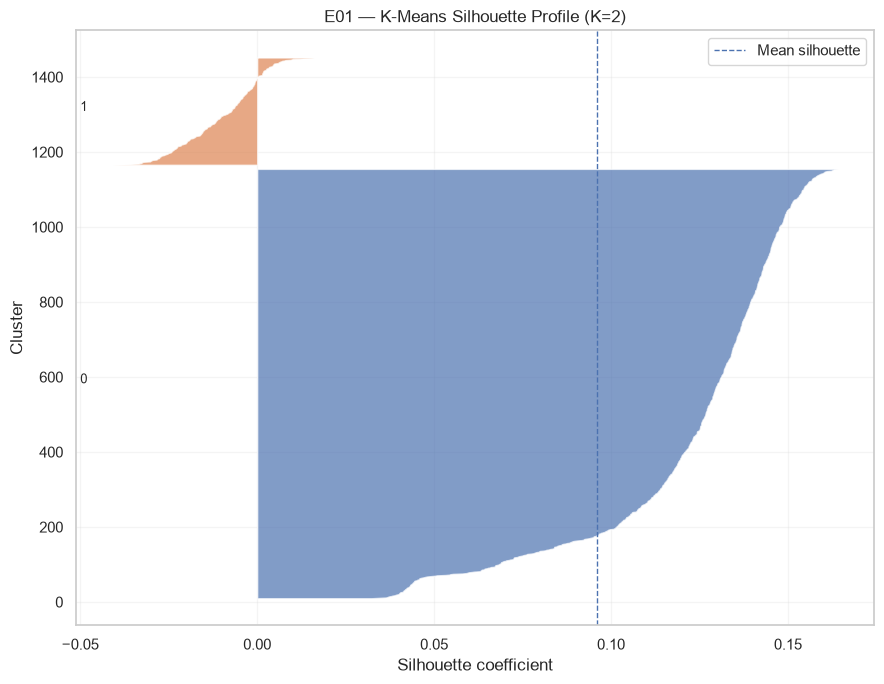

In [10]:
# Inspect the complete silhouette distribution rather than relying only on
# the overall mean score.
e01_silhouette = silhouette_profile(
    X_selected_scaled,
    e01_labels,
)

fig, ax = plt.subplots(figsize=(9, 7))

plot_silhouette_profile(
    e01_silhouette,
    ax=ax,
    title=(
        f"E01 — K-Means Silhouette Profile "
        f"(K={selected_k_candidate})"
    ),
)

fig.tight_layout()
plt.show()

### 3.5.1 Interpretation of the K-Means Silhouette Profile

The observation-level silhouette profile shows how consistently respondents fit their assigned clusters. Positive values indicate better alignment with the assigned cluster, values near zero indicate overlap or boundary observations, and negative values indicate observations that may fit another cluster better. TThe profile must therefore be used to qualify the aggregate silhouette score rather than treating the mean as sufficient evidence of separation.

# 4. E02 — K-Means on the PCA Representation
 
## 4.1 Question
 
Does reducing the selected feature space from 391 variables to 234 PCA components materially change the K-Means clustering structure?
 
## 4.2 Why Repeat K-Means?
 
Repeating the same algorithm with a different representation isolates the effect of dimensionality reduction. The same K range and K-Means configuration are retained so that representation changes can be examined without simultaneously changing the clustering algorithm.
 
Inertia is not compared directly between E01 and E02 because the models operate in different feature spaces. Silhouette and structural consistency are more informative for comparing the two representations.

In [11]:
kmeans_pca_results = []
kmeans_pca_models = {}

# Repeat the K-Means experiment in the reduced PCA representation.
for k in K_RANGE:
    model = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=20,
        random_state=RANDOM_STATE,
    )

    labels = model.fit_predict(X_pca)

    evaluation = evaluate_clustering(
        X_pca,
        labels,
        inertia=model.inertia_,
    )

    kmeans_pca_models[k] = model

    kmeans_pca_results.append(
        {
            "k": k,
            "inertia": evaluation["inertia"],
            "silhouette": evaluation["silhouette"],
            "calinski_harabasz": calinski_harabasz_index(
                X_pca,
                labels,
            ),
        }
    )

kmeans_pca_results = pd.DataFrame(
    kmeans_pca_results
)

display(kmeans_pca_results.round(4))

,k,inertia,silhouette,calinski_harabasz
0,2,486024.5379,0.1015,54.7529
1,3,477410.4797,0.0165,40.7519
2,4,471224.1278,0.0261,33.7588
3,5,468450.5190,0.0277,27.5649
4,6,463900.9467,0.0179,25.0516
5,7,460583.3510,0.0176,22.7239
6,8,457428.5454,0.0130,21.0022


### 4.3.1 Interpretation of the PCA K-Means Results Table
 
The PCA K-Means results table again identifies K=2 as the strongest tested cluster count by silhouette. The approximately 0.1015 silhouette at K=2 is only modestly higher than the E01 value, while larger K values remain close to zero. This indicates that PCA changes the representation without materially changing the broad clustering structure.

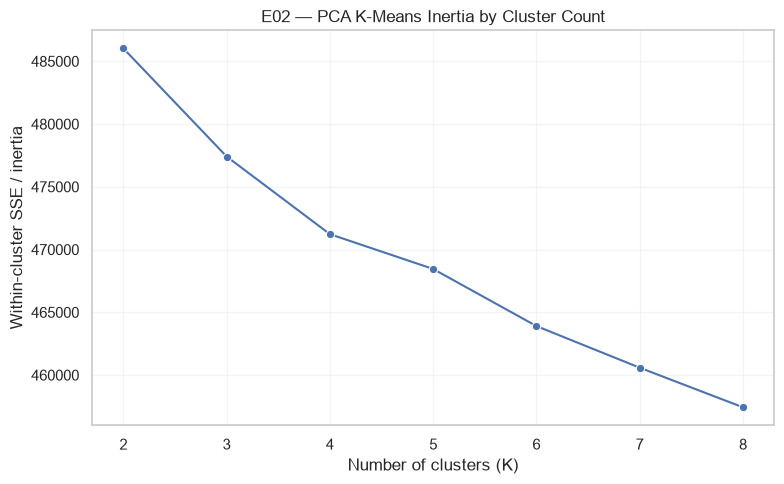

In [12]:
# Examine the PCA representation's inertia curve independently from E01.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_pca_results,
    x="k",
    y="inertia",
    ax=ax,
    title="E02 — PCA K-Means Inertia by Cluster Count",
    xlabel="Number of clusters (K)",
    ylabel="Within-cluster SSE / inertia",
)

fig.tight_layout()
plt.show()

### 4.3.2 Interpretation of the PCA K-Means Inertia/Elbow Figure
 
The PCA inertia curve shows how within-cluster error changes as K increases in the reduced representation. As with E01, the curve is expected to decline as more centroids are introduced. The relevant question is whether the reduction exhibits a convincing diminishing-return point that supports the cluster count selected by the separation diagnostics.

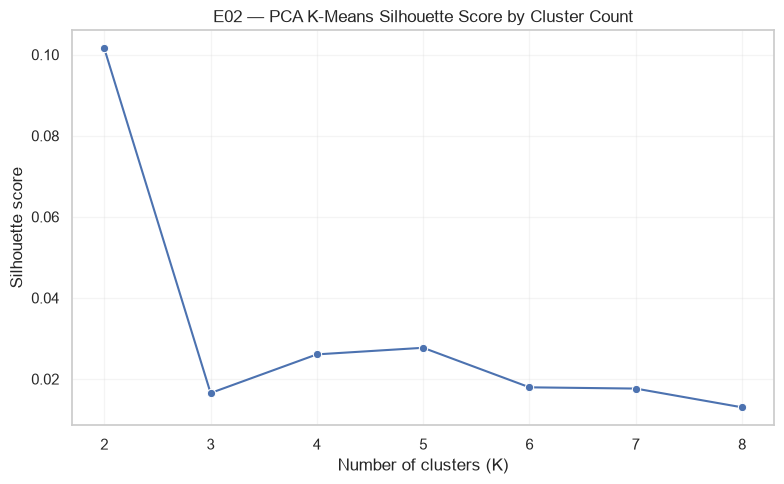

In [13]:
# Compare cohesion and separation across K in the PCA representation.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_pca_results,
    x="k",
    y="silhouette",
    ax=ax,
    title="E02 — PCA K-Means Silhouette Score by Cluster Count",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

### 4.3.3 Interpretation of the PCA K-Means Silhouette Curve
 
The PCA silhouette curve identifies the cluster count with the strongest geometric separation in the reduced representation. The observed maximum at K=2 is substantially above the remaining tested values, making two clusters the strongest tested PCA K-Means candidate. The magnitude remains low, so the result indicates detectable structure rather than strong separation.

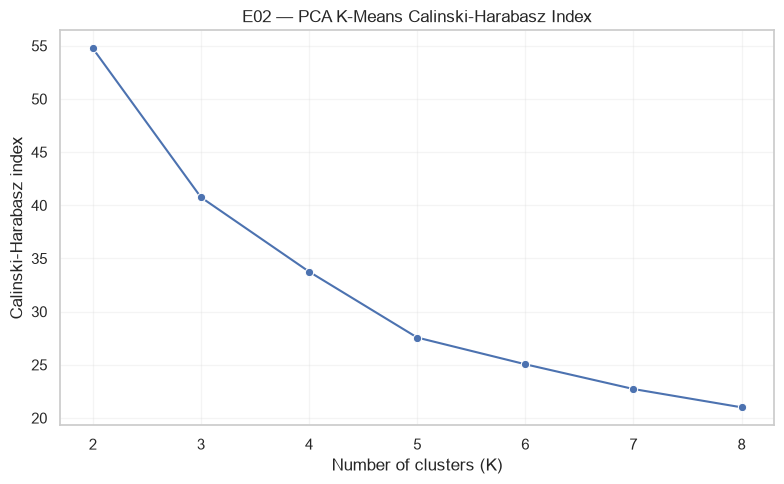

In [14]:
# Compare the PCA K-Means solutions using a second dispersion-based
# diagnostic alongside inertia and silhouette.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    kmeans_pca_results,
    x="k",
    y="calinski_harabasz",
    ax=ax,
    title="E02 — PCA K-Means Calinski-Harabasz Index",
    xlabel="Number of clusters (K)",
    ylabel="Calinski-Harabasz index",
)

fig.tight_layout()
plt.show()

### 4.3.4 Interpretation of the PCA K-Means Calinski-Harabasz Diagnostic
 
The Calinski-Harabasz diagnostic provides an independent dispersion-based comparison of the PCA K-Means partitions. Its preferred K should be compared with the silhouette preference without collapsing the two criteria into a single score. Agreement strengthens the case for the corresponding candidate; disagreement indicates that the representation contains structure that is sensitive to the evaluation criterion.

In [15]:
# Select the strongest PCA K candidate from the corrected silhouette results.
if kmeans_pca_results["silhouette"].notna().sum() == 0:
    raise ValueError(
        "No valida PCA K-Means silhouette scores were produced."
    )

pca_k_candidate = int(
    kmeans_pca_results.loc[
        kmeans_pca_results["silhouette"].idxmax(),
        "k",
    ]
)

e02_model = kmeans_pca_models[pca_k_candidate]
e02_labels = e02_model.labels_

e02_evaluation = evaluate_clustering(
    X_pca,
    e02_labels,
    inertia=e02_model.inertia_,
)
e02_evaluation["calinski_harabasz"] = calinski_harabasz_index(
    X_pca,
    e02_labels,
)

### 4.4.1 Interpretation of the Selected PCA K-Means Candidate
 
The PCA K-Means candidate is selected using the highest valid silhouette score among the tested cluster counts. This identifies the partition carried forward for detailed inspection and provides a controlled comparison with the selected-feature baseline in E01.

In [16]:
# Display the population share assigned to each selected PCA K-Means cluster.
display(
    cluster_size_table(e02_labels)
)

,cluster,count,percentage,cluster_type
0,0,1146,79.972087,Cluster
1,1,287,20.027913,Cluster


### 4.4.2 Interpretation of the E02 Cluster-Size Table
 
The PCA K-Means solution produces the same 1,146/287 allocation as E01, corresponding to approximately 79.97% and 20.03% of respondents. The persistence of this split after dimensionality reduction indicates that the broad partition is not dependent on the full 391-feature representation. It does not, however, establish substantive meaning for the two groups.

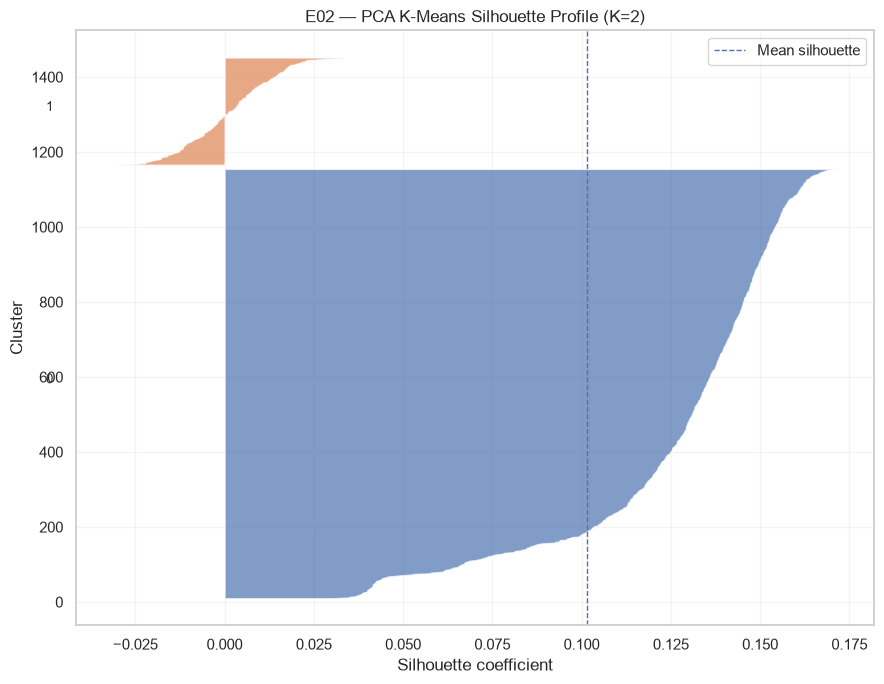

In [17]:
# Examine whether the mean silhouette is supported by the observation-level
# silhouette distribution.
e02_silhouette = silhouette_profile(
    X_pca,
    e02_labels,
)

fig, ax = plt.subplots(figsize=(9, 7))

plot_silhouette_profile(
    e02_silhouette,
    ax=ax,
    title=f"E02 — PCA K-Means Silhouette Profile (K={pca_k_candidate})",
)

fig.tight_layout()
plt.show()

### 4.5.1 Interpretation of the PCA K-Means Silhouette Profile
 
The silhouette profile provides observation-level evidence about the stability of the PCA K-Means assignment. The profile should be read for the amount of positive area, observations close to zero, and negative observations. These features determine whether the mean silhouette represents broadly consistent separation or masks substantial overlap.

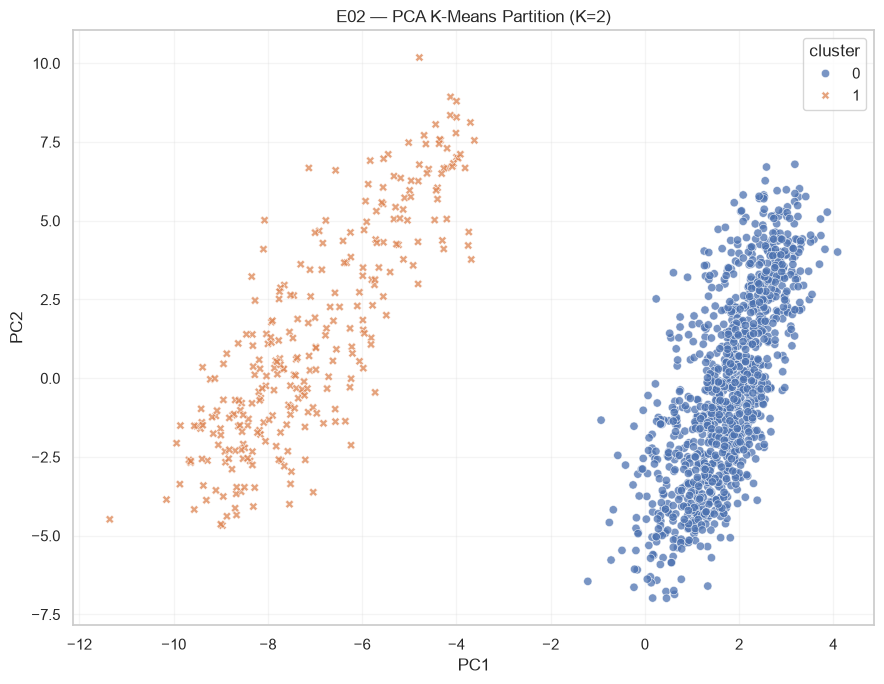

In [18]:
# Visualise the E02 assignments using the first two principal components.
# The clustering model itself was fitted using all 234 PCA components.
fig, ax = plt.subplots(figsize=(9, 7))

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e02_labels,
    ax=ax,
    title=f"E02 — PCA K-Means Partition (K={pca_k_candidate})",
    x_label="PC1",
    y_label="PC2",
)

fig.tight_layout()
plt.show()

### 4.6.1 Interpretation of the PCA K-Means Projection
 
The PC1/PC2 projection is a visual aid only; the model was fitted using all retained PCA components. The figure shows whether the selected assignments correspond to a visible broad structure in the first two principal directions. It should not be treated as a two-dimensional reconstruction of the full clustering space.

# 5. E03 — Gaussian Mixture Model
 
## 5.1 Question
 
Does a probabilistic clustering model reveal structure that is not adequately represented by hard K-Means assignments?

## 5.2 Why GMM?
 
K-Means assigns every observation to one cluster with a hard assignment. GMM instead represents each cluster through a Gaussian probability distribution and provides membership probabilities. This distinction matters when groups overlap.
 
GMM also incorporates variance-covariance structure, allowing it to represent elliptical clusters that are not naturally represented by centroid-only K-Means. The model therefore provides a meaningful alternative rather than simply another implementation of the same clustering assumption.

## 5.3 Why PCA?

A full covariance GMM becomes increasingly parameter-heavy as the number of features increases. The PCA representation reduces the feature space from 391 selected variables to 234 components and therefore provides a more manageable representation for this probabilistic experiment.

## 5.4 Why BIC and Silhouette?

BIC evaluates model fit while penalising unnecessary complexity. Silhouette evaluates geometric cohesion and separation. They therefore answer different questions. The two diagnostics are therefore retained rather than collapsed into a single score.

In [19]:
gmm_results = []
gmm_models = {}

# Evaluate several component counts using the full covariance structure
# because covariance is part of the methodological distinction from K-Means.
for components in GMM_COMPONENT_RANGE:
    model = GaussianMixture(
        n_components=components,
        covariance_type="full",
        n_init=10,
        max_iter=500,
        random_state=RANDOM_STATE,
    )

    model.fit(X_pca)

    labels = model.predict(X_pca)
    probabilities = model.predict_proba(X_pca)

    evaluation = evaluate_clustering(
        X_pca,
        labels,
        bic=model.bic(X_pca),
        aic=model.aic(X_pca),
    )

    gmm_models[components] = model

    gmm_results.append(
        {
            "components": components,
            "bic": evaluation["bic"],
            "aic": model.aic(X_pca),
            "silhouette": evaluation["silhouette"],
            "mean_max_membership": probabilities.max(
                axis=1
            ).mean(),
            "converged": model.converged_,
            "iterations": model.n_iter_,
        }
    )

gmm_results = pd.DataFrame(gmm_results)

display(
    gmm_results.round(4)
)

,components,bic,aic,silhouette,mean_max_membership,converged,iterations
0,2,1.080067e+06,787934.8317,0.1090,1.0,True,12
1,3,8.717437e+05,433543.5193,0.0836,1.0,True,8
2,4,1.071107e+06,486837.8558,0.0842,1.0,True,9
3,5,8.593494e+05,129012.2282,0.0186,1.0,True,8
4,6,1.025468e+06,149062.4637,0.0059,1.0,True,2
5,7,9.913242e+05,-31149.8434,-0.0188,1.0,True,31
6,8,1.046149e+06,-122393.1340,-0.0106,1.0,True,15


### 5.5.1 Interpretation of the GMM Results Table

The GMM results table shows that different component counts lead to different conclusions under BIC and silhouette. The five-component model has the lowest BIC among the tested configurations, while the two-component model has the strongest silhouette. This disagreement is analytically important because probabilistic model fit and geometric separation measure different properties of the data.

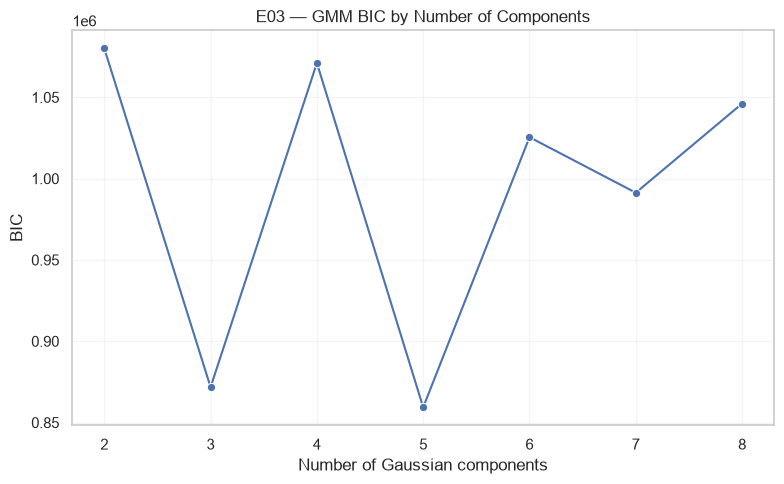

In [20]:
# Lower BIC indicates a better fit under the BIC criterion.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    gmm_results,
    x="components",
    y="bic",
    ax=ax,
    title="E03 — GMM BIC by Number of Components",
    xlabel="Number of Gaussian components",
    ylabel="BIC",
)

fig.tight_layout()
plt.show()

### 5.6.1 Interpretation of the GMM BIC Figure

The BIC curve reaches its minimum at five components. Under BIC, this is the preferred model among the tested component counts because the criterion balances likelihood fit against model complexity. BIC does not, however, establish that the resulting components are geometrically well separated.

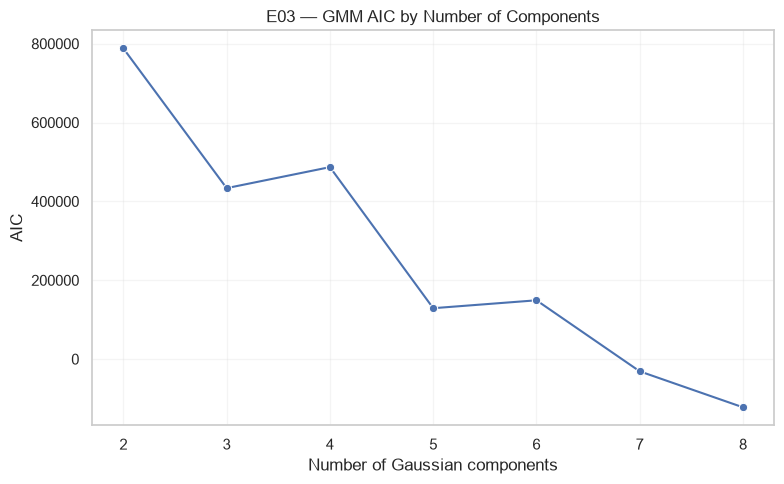

In [21]:
# AIC provides a second likelihood-based model-complexity diagnostic
# alongside BIC. Lower values indicate a prefered balance under criterion.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    gmm_results,
    x="components",
    y="aic",
    ax=ax,
    title="E03 — GMM AIC by Number of Components",
    xlabel="Number of Gaussian components",
    ylabel="AIC",
)

fig.tight_layout()
plt.show()

### 5.7.1 Interpretation of the GMM AIC Figure

The AIC curve provides a second likelihood-based model-complexity comparison. Its preferred component count should be interpreted relative to BIC rather than assumed to be identical. Agreement would provide additional support for a component count; disagreement would show sensitivity to the complexity penalty used by the information criterion.

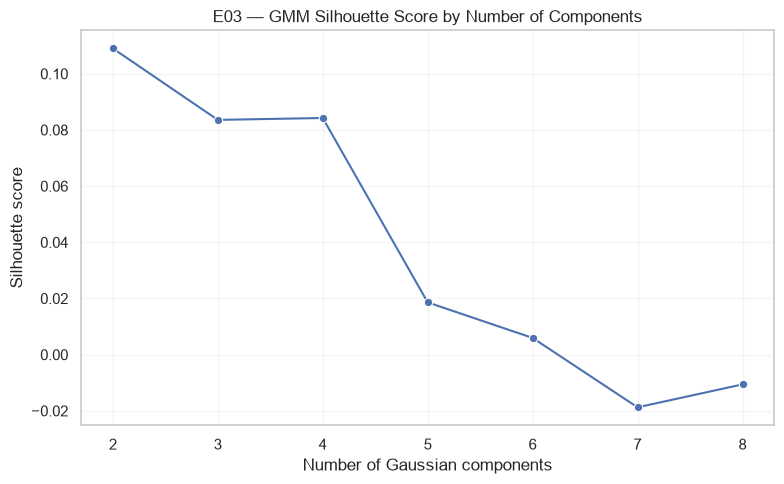

In [22]:
# Silhouette provides a geometric evaluation complementary to BIC.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    gmm_results,
    x="components",
    y="silhouette",
    ax=ax,
    title="E03 — GMM Silhouette Score by Number of Components",
    xlabel="Number of Gaussian components",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

### 5.8.1 Interpretation of the GMM Silhouette Curve
 
The GMM silhouette curve favours two components, while the BIC criterion favours five. The decline in silhouette as component count increases indicates that the additional components do not correspond to increasingly well-separated geometric groups. The five-component GMM must therefore be retained as a BIC-selected statistical candidate, not as evidence of five clearly separated clusters.

In [23]:
# Use the lowest-BIC model as the primary GMM candidate because BIC explicitly
# accounts for model complexity.
gmm_component_candidate = int(
    gmm_results.loc[
        gmm_results["bic"].idxmin(),
        "components",
    ]
)

e03_model = gmm_models[gmm_component_candidate]
e03_labels = e03_model.predict(X_pca)
e03_probabilities = e03_model.predict_proba(X_pca)

e03_evaluation = evaluate_clustering(
    X_pca,
    e03_labels,
    bic=e03_model.bic(X_pca),
    aic=e03_model.aic(X_pca),
)

### 5.9.1 Interpretation of the Selected GMM Candidate
 
The five-component GMM is retained because it has the lowest BIC among the tested component counts. This is explicitly a BIC-based model-selection decision. The cluster size, membership probability, and silhouette outputs determine whether that statistically preferred model is substantively useful.

In [24]:
# Display the population share assigned to each selected GMM component.
display(
    cluster_size_table(e03_labels)
)

,cluster,count,percentage,cluster_type
0,0,730,50.942080,Cluster
1,1,283,19.748779,Cluster
2,2,24,1.674808,Cluster
3,3,198,13.817167,Cluster
4,4,198,13.817167,Cluster


### 5.9.2 Interpretation of the GMM Cluster-Size Table
 
The five-component GMM produces uneven component sizes: one component contains roughly half the sample, another roughly one fifth, two components are of similar intermediate size, and one component is very small. The small component requires particular caution because a statistically fitted component is not automatically a substantively meaningful respondent group.

In [25]:
# Summarise posterior membership strength to determine whether the model is
# meaningfully soft or effectively behaving like hard clustering.
e03_membership_summary = pd.DataFrame(
    {
        "maximum_membership_probability": (
            e03_probabilities.max(axis=1)
        )
    }
)

display(
    e03_membership_summary.describe().round(4)
)

,maximum_membership_probability
count,1433.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


### 5.10.1 Interpretation of the GMM Membership-Probability Output

The posterior membership summary shows maximum membership probabilities effectively equal to 1.0 for the observations in the selected solution. This means the fitted GMM is behaving almost like hard assignment rather than expressing substantial uncertainty between components. The result weakens one of the principal interpretive advantages of a probabilistic clustering model in this particular representation.

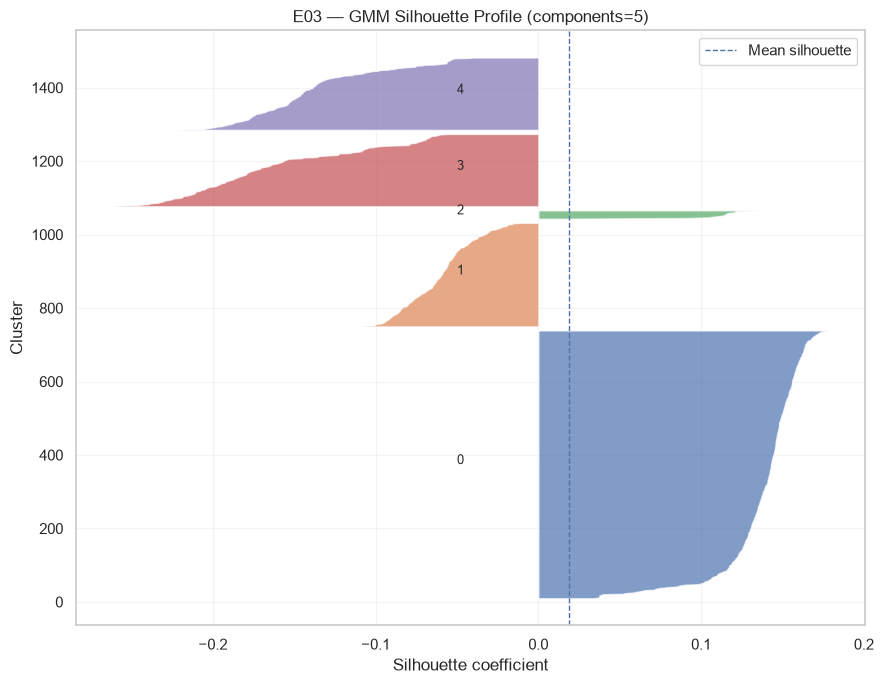

In [26]:
# Inspect the observation-level silhouette structure for the selected GMM.
e03_silhouette = silhouette_profile(
    X_pca,
    e03_labels,
)

fig, ax = plt.subplots(figsize=(9, 7))

plot_silhouette_profile(
    e03_silhouette,
    ax=ax,
    title=(
        f"E03 — GMM Silhouette Profile "
        f"(components={gmm_component_candidate})"
    ),
)

fig.tight_layout()
plt.show()

### 5.11.1 Interpretation of the GMM Silhouette Profile
 
The silhouette profile shows substantial observations near or below zero across the five components. This indicates weak geometric separation and substantial overlap between component assignments. The profile therefore qualifies the BIC result: statistical fit favours five components, but the five groups should not be interpreted as five clearly separated respondent populations.

# 6. E04 — Agglomerative Hierarchical Clustering
 
## 6.1 Question
 
Does the respondent population exhibit a hierarchical structure in which
groups progressively merge as the required similarity becomes less restrictive?

## 6.2 Why Hierarchical Clustering?

K-Means and GMM produce a partition for a selected number of clusters.
 
Agglomerative hierarchical clustering instead begins with individual
observations and progressively merges groups. The resulting hierarchy provides a dendrogram that exposes the structure across multiple possible levels of clustering. This makes hierarchical clustering useful as a structural cross-check rather than simply another way to obtain labels.

## 6.3 Why Ward Linkage?

The PCA representation is continuous numerical data.

Ward linkage is therefore used as the primary hierarchical method because it
selects merges by considering the increase in within-cluster squared error. This aligns naturally with the compact distance-based structure already
examined through K-Means.

Single linkage can produce chaining, while complete and average linkage make
different assumptions about how group-to-group dissimilarity should be
measured. Those alternatives are therefore not added merely for completeness. Ward is the primary linkage because its objective is most directly aligned with the standardized/PCA numerical representation and the clustering question being investigated.

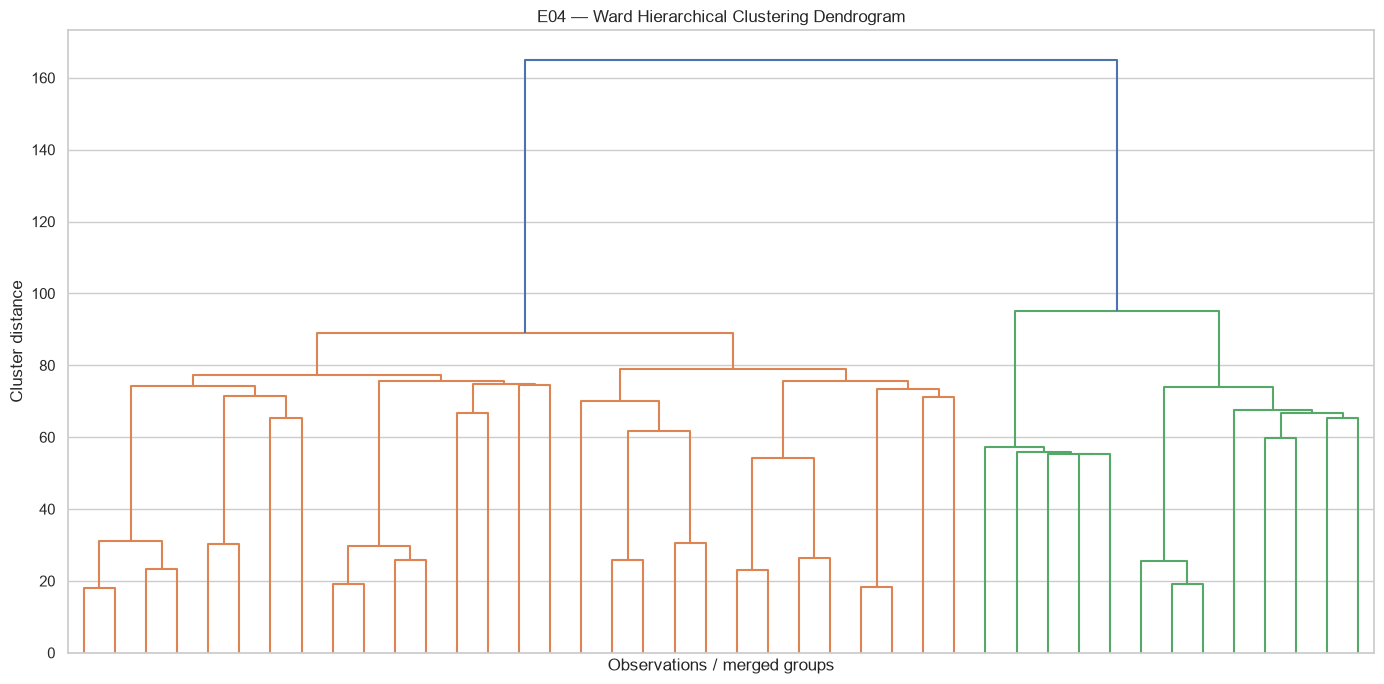

In [27]:
# Construct the complete Ward hierarchy once so that the dendrogram and
# subsequent candidate cuts describe the same hierarchical structure.
hierarchical_linkage = linkage(
    X_pca,
    method="ward",
    metric="euclidean",
)

fig, ax = plt.subplots(figsize=(14, 7))

plot_dendrogram(
    hierarchical_linkage,
    ax=ax,
    title="E04 — Ward Hierarchical Clustering Dendrogram",
    truncate_level=5,
)

fig.tight_layout()
plt.show()

### 6.3.1 Interpretation of the Ward Dendrogram

The dendrogram shows a pronounced high-level merge separating two broad branches, followed by additional internal merging structure. This supports investigating a two-group cut while also showing that finer substructure exists within the branches. The dendrogram is therefore structural evidence for candidate cut levels, not proof that any single cut is substantively meaningful.

### 6.4 Additional Diagnostic — Cophenetic Correlation

The dendrogram shows the hierarchy visually, but it is also useful to quantify how faithfully the hierarchy preserves the original pairwise distances.

Cophenetic correlation measures the agreement between the original pairwise distances and the distances implied by the dendrogram. A higher value indicates that the hierarchical representation preserves the observed distance relationships more faithfully.

This metric evaluates the quality of the hierarchy itself rather than selecting a particular cluster count. The dendrogram and silhouette analysis are therefore still required when deciding where the hierarchy should be cut.

In [28]:
# Quantify how faithfully the Ward dendrogram preserves the pairwise
# distance structure of the PCA representation.
ward_cophenetic_correlation = cophenetic_correlation(
    hierarchical_linkage,
    X_pca,
)

print(
    "Ward cophenetic correlation: "
    f"{ward_cophenetic_correlation:.4f}"
)

Ward cophenetic correlation: 0.1618


### 6.4.1 Interpretation of the Cophenetic Correlation

The cophenetic correlation measures how faithfully the Ward hierarchy represents the pairwise distance relationships used to construct it. A higher value indicates stronger fidelity to the original distance structure. This diagnostic evaluates the quality of the hierarchy itself and is not used to select the final number of clusters.

In [29]:
hierarchical_results = []

# Evaluate candidate cuts from the same Ward hierarchy.
for k in K_RANGE:
    model = AgglomerativeClustering(
        n_clusters=k,
        linkage="ward",
    )

    labels = model.fit_predict(X_pca)

    evaluation = evaluate_clustering(
        X_pca,
        labels,
    )

    hierarchical_results.append(
        {
            "k": k,
            "silhouette": evaluation["silhouette"],
        }
    )

hierarchical_results = pd.DataFrame(
    hierarchical_results
)

display(
    hierarchical_results.round(4)
)

,k,silhouette
0,2,0.0840
1,3,0.0514
2,4,0.0087
3,5,0.0065
4,6,0.0078
5,7,-0.0012
6,8,0.0012


### 6.5.1 Interpretation of the Hierarchical Results Table

The hierarchical results table shows the silhouette values for the tested cuts. K=2 has the strongest silhouette, with the score declining substantially for larger cluster counts. This makes the two-cluster cut the strongest tested candidate under the geometric separation criterion.

In [30]:
# Select the strongest silhouette candidate for detailed structural inspection.
if hierarchical_results["silhouette"].notna().sum() == 0:
    raise ValueError(
        "No valid hierarchical silhouette scores were produced."
    )

hierarchical_k_candidate = int(
    hierarchical_results.loc[
        hierarchical_results["silhouette"].idxmax(),
        "k",
    ]
)

e04_model = AgglomerativeClustering(
    n_clusters=hierarchical_k_candidate,
    linkage="ward",
)

e04_labels = e04_model.fit_predict(X_pca)

e04_evaluation = evaluate_clustering(
    X_pca,
    e04_labels,
)
e04_evaluation["cophenetic_correlation"] = ward_cophenetic_correlation

### 6.6.1 Interpretation of the Selected Ward Candidate

The Ward candidate is selected using the highest valid silhouette score among the tested cuts. This identifies the partition for detailed structural inspection while leaving substantive meaning to the cluster-profiling stage.

In [31]:
# Display the population share assigned to each selected Ward cluster.
display(
    cluster_size_table(e04_labels)
)

,cluster,count,percentage,cluster_type
0,0,227,15.840893,Cluster
1,1,1206,84.159107,Cluster


### 6.7.1 Interpretation of the Ward Cluster-Size Table

The Ward K=2 solution produces an approximately 84/16 split: 1,206 respondents in the larger cluster and 227 in the smaller cluster. Both groups are sufficiently represented for profiling, but the imbalance is material and will be considered when comparing cluster-level summaries in Notebook 05.

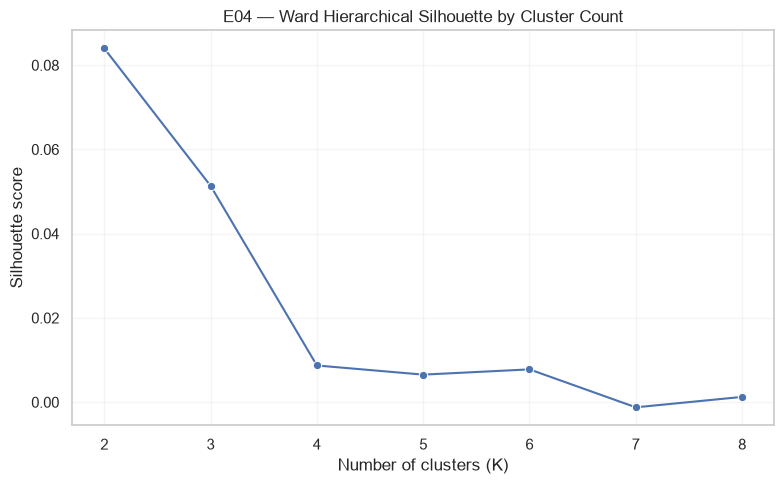

In [32]:
# Compare candidate hierarchical cuts using silhouette.
fig, ax = plt.subplots(figsize=(8, 5))

plot_metric_curve(
    hierarchical_results,
    x="k",
    y="silhouette",
    ax=ax,
    title="E04 — Ward Hierarchical Silhouette by Cluster Count",
    xlabel="Number of clusters (K)",
    ylabel="Silhouette score",
)

fig.tight_layout()
plt.show()

### 6.8.1 Interpretation of the Ward Silhouette Curve

The silhouette curve reaches its maximum at K=2 and falls sharply for larger cuts. The result supports investigating two broad groups rather than interpreting the smaller gains from additional cuts as evidence of well-separated subgroups.

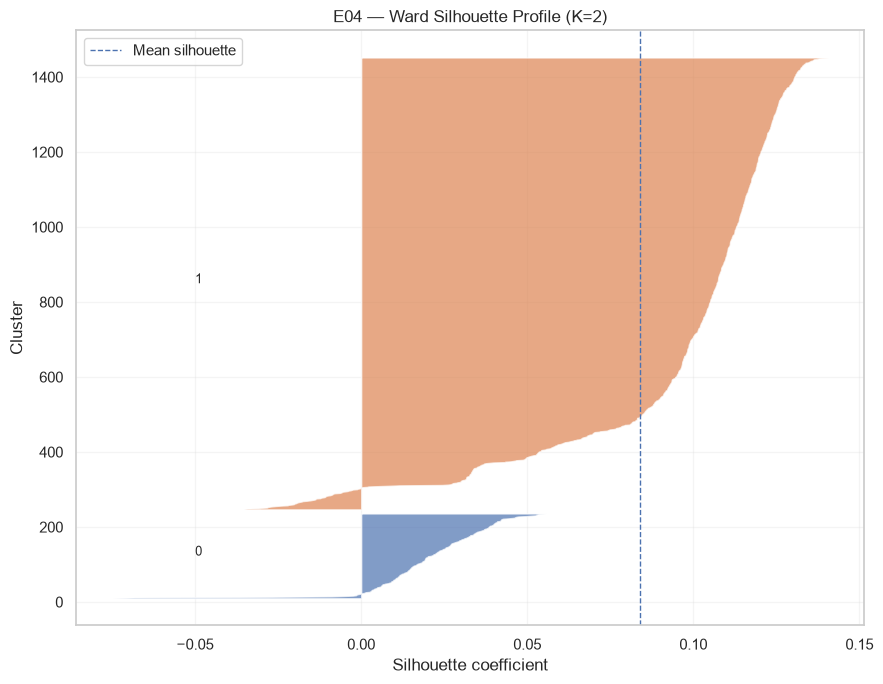

In [33]:
# Inspect whether the hierarchical candidate's mean silhouette is supported
# by the observation-level silhouette distribution.
e04_silhouette = silhouette_profile(
    X_pca,
    e04_labels,
)

fig, ax = plt.subplots(figsize=(9, 7))

plot_silhouette_profile(
    e04_silhouette,
    ax=ax,
    title=(
        f"E04 — Ward Silhouette Profile "
        f"(K={hierarchical_k_candidate})"
    ),
)

fig.tight_layout()
plt.show()

### 6.9.1 Interpretation of the Ward Silhouette Profile

The silhouette profile shows that the larger Ward cluster contains many positive observations, while the smaller cluster includes observations close to zero and below zero. The result indicates a detectable broad partition with substantial overlap rather than two sharply separated groups.

# 7. E05 — DBSCAN

## 7.1 Question

Does the PCA representation contain sufficiently distinct density regions to justify density-based clustering?

## 7.1.1 Why DBSCAN?

DBSCAN makes a fundamentally different assumption from K-Means, GMM and
hierarchical clustering.

It identifies dense regions rather than requiring a predefined number of
clusters.

It can therefore:

- identify groups with irregular boundaries;
- identify observations that do not belong to dense regions;
- operate without specifying the number of clusters in advance.

This makes it particularly useful as a diagnostic of whether density separation exists in the data.

A poor DBSCAN result is still informative.

If reasonable changes in `eps` and `min_samples` repeatedly produce one
dominant cluster, excessive noise, or unstable segmentation, the evidence
suggests that the respondent population does not contain clearly separated
density regions under the tested representation.

DBSCAN will therefore not be forced into a final clustering solution.

## 7.2 Initial DBSCAN Parameter Sensitivity

A broad but controlled parameter range is first evaluated to establish how the density structure changes as `eps` and `min_samples` vary. This experiment is exploratory: it is intended to reveal sensitivity and candidate regions, not to declare a final DBSCAN configuration.

In [34]:
# Use a controlled grid that extends below the previous eps range.
# The purpose is to determine whether smaller neighbourhoods reveal multiple
# dense regions rather than immediately producing one dominant cluster.
dbscan_eps_values = np.arange(
    2.0,
    16.0,
    1.0,
)

dbscan_min_samples_values = [5, 10]

display(
    pd.DataFrame(
        {
            "candidate_eps": dbscan_eps_values,
        }
    )
)

,candidate_eps
0,2.0
1,3.0
2,4.0
3,5.0
4,6.0
5,7.0
6,8.0
7,9.0
8,10.0
9,11.0


### 7.2.1 Interpretation of the DBSCAN Candidate-eps Output

The broad candidate range deliberately covers small neighbourhood radii through the region where substantive clusters previously began to appear. The purpose is sensitivity analysis: DBSCAN can change abruptly as `eps` changes, so the parameter should be examined as a range rather than assumed to have one predetermined value.

In [35]:
dbscan_results = []
dbscan_models = {}

# Evaluate the density-based model across a deliberately limited parameter
# grid so that changes in cluster structure can be inspected directly.
for min_samples in dbscan_min_samples_values:
    for eps in dbscan_eps_values:
        model = DBSCAN(
            eps=float(eps),
            min_samples=min_samples,
            metric="euclidean",
        )

        labels = model.fit_predict(X_pca)

        evaluation = evaluate_clustering(
            X_pca,
            labels,
        )

        dbscan_models[
            (float(eps), min_samples)
        ] = model

        dbscan_results.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": evaluation["n_clusters"],
                "n_noise": evaluation["n_noise"],
                "noise_fraction": evaluation["noise_fraction"],
                "silhouette": evaluation["silhouette"],
            }
        )

dbscan_results = pd.DataFrame(
    dbscan_results
)

display(
    dbscan_results.round(4)
)

,eps,min_samples,n_clusters,n_noise,noise_fraction,silhouette
0,2.0,5,0,1433,1.0000,NaN
1,3.0,5,0,1433,1.0000,NaN
2,4.0,5,0,1433,1.0000,NaN
3,5.0,5,0,1433,1.0000,NaN
4,6.0,5,0,1433,1.0000,NaN
5,7.0,5,0,1433,1.0000,NaN
6,8.0,5,0,1433,1.0000,NaN
7,9.0,5,0,1433,1.0000,NaN
8,10.0,5,0,1433,1.0000,NaN
9,11.0,5,3,1411,0.9846,0.1398


### 7.2.2 Interpretation of the DBSCAN Sensitivity-Results Table

The DBSCAN sensitivity table shows that low `eps` values classify essentially the entire dataset as noise. Substantive clusters begin to appear only as the neighbourhood radius increases, and the resulting number of clusters and noise fraction change rapidly. This establishes strong parameter sensitivity before any candidate is selected.

## 7.3 Data-Informed `eps` Diagnostic

The initial DBSCAN grid provides a controlled sensitivity analysis, but the
`eps` range should also be informed by the local distance structure of the
data.

A K-distance curve orders observations by their distance to the kth nearest
neighbour. A pronounced change in the curve indicates a transition from
relatively dense observations to increasingly isolated observations.

A geometric knee estimate is used only as a starting point for the subsequent DBSCAN parameter experiment. It is not treated as a mathematically unique or automatically correct `eps` value.

The resulting candidate must still be assessed through cluster count, noise
proportion, cluster sizes, and the resulting structure.

Estimated K-distance knee: eps ≈ 17.4460


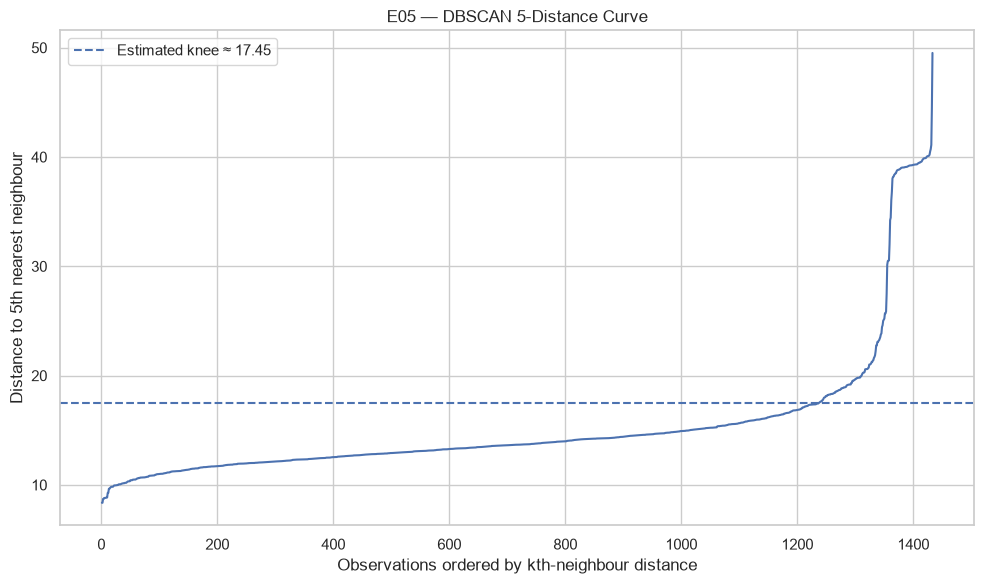

In [36]:
# Use the same neighbour rank as the baseline DBSCAN min_samples setting
# to make the K-distance diagnostic directly relevant to the parameter search.
DBSCAN_K_DISTANCE_NEIGHBORS = 5

dbscan_k_distance = k_distance_profile(
    X_pca,
    n_neighbors=DBSCAN_K_DISTANCE_NEIGHBORS,
)

dbscan_eps_knee = estimate_knee_from_k_distance(
    dbscan_k_distance,
)

print(
    f"Estimated K-distance knee: eps ≈ {dbscan_eps_knee:.4f}"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    dbscan_k_distance["observation_order"],
    dbscan_k_distance["k_distance"],
)

ax.axhline(
    dbscan_eps_knee,
    linestyle="--",
    label=f"Estimated knee ≈ {dbscan_eps_knee:.2f}",
)

ax.set_title(
    f"E05 — DBSCAN {DBSCAN_K_DISTANCE_NEIGHBORS}-Distance Curve"
)
ax.set_xlabel("Observations ordered by kth-neighbour distance")
ax.set_ylabel(
    f"Distance to {DBSCAN_K_DISTANCE_NEIGHBORS}th nearest neighbour"
)
ax.legend()

fig.tight_layout()
plt.show()

### 7.3.1 Interpretation of the K-Distance Curve

The K-distance curve is used to identify a data-informed transition in local neighbourhood density. The estimated knee is a deterministic geometric candidate region for `eps`, not a mathematically guaranteed optimum. Its value is useful only insofar as nearby DBSCAN configurations produce substantively useful cluster coverage and stability.

## 7.4 Focused DBSCAN Experiment Around the K-Distance Knee

The initial parameter grid establishes how DBSCAN behaves across a broad
range of neighbourhood radii.

The K-distance diagnostic now provides a narrower, data-informed region for
additional testing. The purpose is not to force the knee value into the final solution, but to determine whether nearby `eps` values produce a better balance between substantive clusters and noise.

In [37]:
# Test a focused neighbourhood around the estimated K-distance knee.
# The range deliberately includes values below and above the knee so that
# the sensitivity of the resulting density structure can be examined.
dbscan_knee_eps_values = np.round(
    np.arange(
        max(0.5, dbscan_eps_knee - 2.0),
        dbscan_eps_knee + 2.01,
        0.5,
    ),
    2,
)

dbscan_knee_results = []
dbscan_knee_models = {}

for min_samples in dbscan_min_samples_values:
    for eps in dbscan_knee_eps_values:
        model = DBSCAN(
            eps=float(eps),
            min_samples=min_samples,
            metric="euclidean",
        )

        labels = model.fit_predict(X_pca)

        evaluation = evaluate_clustering(
            X_pca,
            labels,
        )

        dbscan_knee_models[
            (float(eps), min_samples)
        ] = model

        dbscan_knee_results.append(
            {
                "eps": eps,
                "min_samples": min_samples,
                "n_clusters": evaluation["n_clusters"],
                "n_noise": evaluation["n_noise"],
                "noise_fraction": evaluation["noise_fraction"],
                "silhouette": evaluation["silhouette"],
            }
        )

dbscan_knee_results = pd.DataFrame(
    dbscan_knee_results
)

display(
    dbscan_knee_results.round(4)
)

,eps,min_samples,n_clusters,n_noise,noise_fraction,silhouette
0,15.45,5,7,458,0.3196,0.0780
1,15.95,5,8,388,0.2708,0.1202
2,16.45,5,9,341,0.2380,0.1302
3,16.95,5,9,312,0.2177,0.1067
4,17.45,5,6,282,0.1968,0.0944
5,17.95,5,2,267,0.1863,0.1514
6,18.45,5,2,255,0.1779,0.1497
7,18.95,5,1,242,0.1689,NaN
8,19.45,5,1,225,0.1570,NaN
9,15.45,10,1,556,0.3880,NaN


### 7.4.1 Interpretation of the Focused DBSCAN Results

The focused experiment tests nearby `eps` values around the estimated knee for both `min_samples` settings. The output should be read primarily for the joint behaviour of cluster count, noise fraction, and silhouette. A higher silhouette is not sufficient if it is achieved by assigning most respondents to noise.

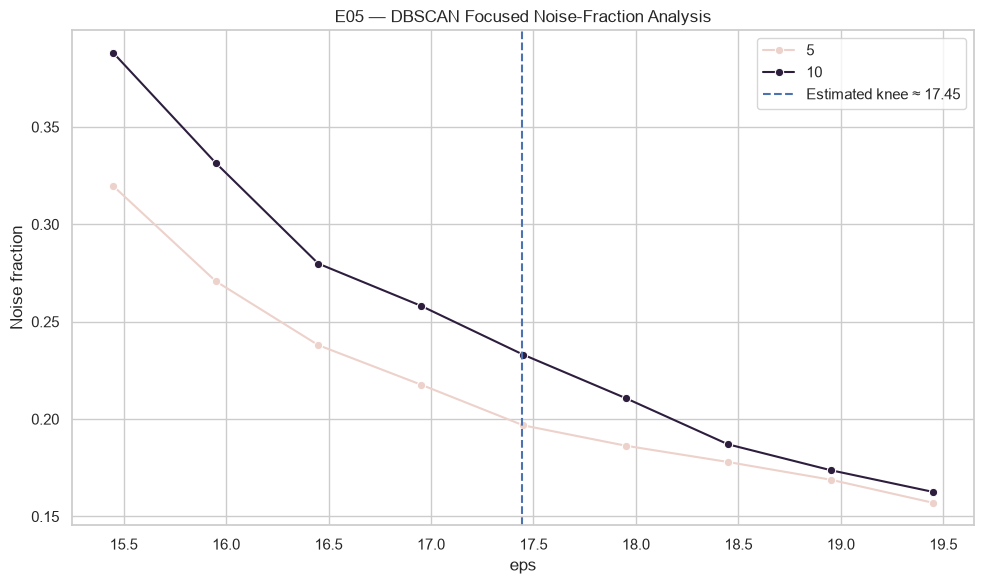

In [38]:
# Visualise the trade-off between noise and detected cluster structure
# within the data-informed neighbourhood around the estimated knee.
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(
    data=dbscan_knee_results,
    x="eps",
    y="noise_fraction",
    hue="min_samples",
    marker="o",
    ax=ax,
)

ax.axvline(
    dbscan_eps_knee,
    linestyle="--",
    label=f"Estimated knee ≈ {dbscan_eps_knee:.2f}",
)

ax.set_title("E05 — DBSCAN Focused Noise-Fraction Analysis")
ax.set_xlabel("eps")
ax.set_ylabel("Noise fraction")
ax.legend()

fig.tight_layout()
plt.show()

### 7.4.2 Interpretation of the Focused Noise-Fraction Figure

The focused noise-fraction figure shows how the proportion of unassigned observations changes immediately around the K-distance knee. It is useful for identifying whether small movements around the data-informed candidate produce a materially better population coverage. The figure does not establish an optimum by itself; the corresponding cluster count and substantive coverage remain necessary.

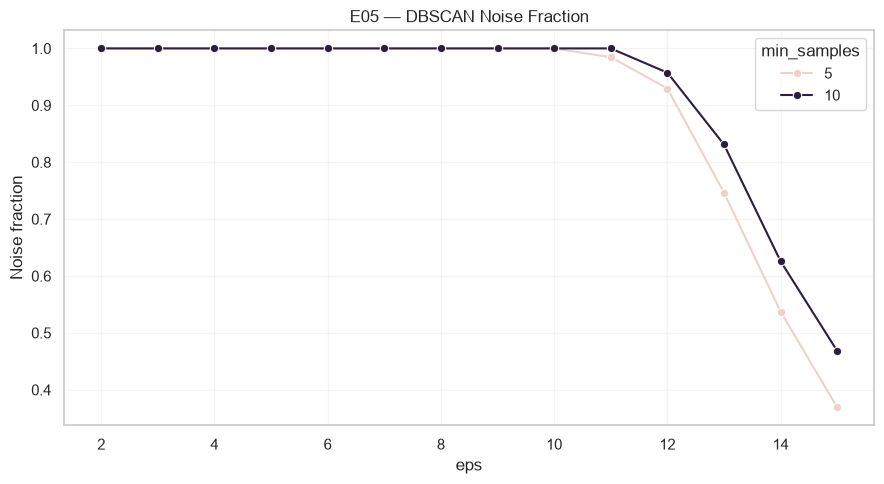

In [39]:
# Examine how the noise fraction changes as the neighbourhood radius grows.
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=dbscan_results,
    x="eps",
    y="noise_fraction",
    hue="min_samples",
    marker="o",
    ax=ax,
)

ax.set_title("E05 — DBSCAN Noise Fraction")
ax.set_xlabel("eps")
ax.set_ylabel("Noise fraction")
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

### 7.5.1 Interpretation of the DBSCAN Noise-Fraction Figure

The noise-fraction curve shows how rapidly observations enter substantive density regions as `eps` increases. The sharp decline from near-total noise demonstrates strong parameter sensitivity. A useful population-wide DBSCAN solution would require a materially lower noise fraction without collapsing the density structure into an undifferentiated cluster.

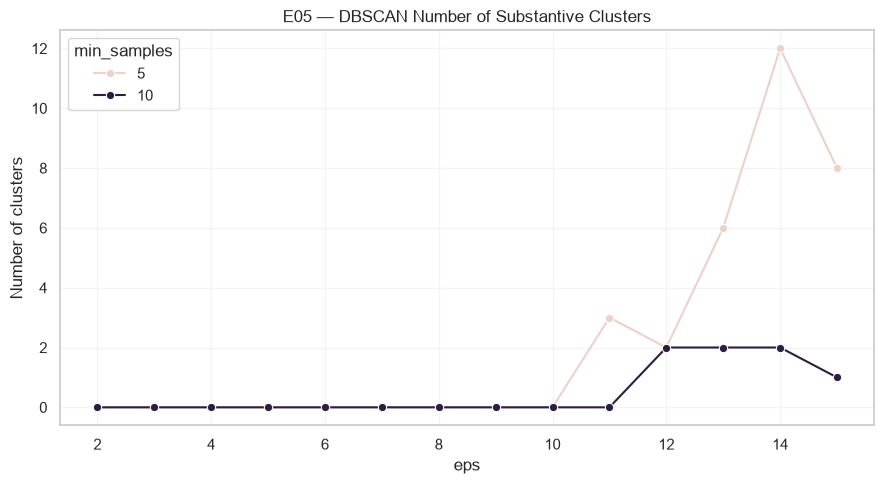

In [40]:
# Examine whether the parameter search produces multiple substantive clusters.
fig, ax = plt.subplots(figsize=(9, 5))

sns.lineplot(
    data=dbscan_results,
    x="eps",
    y="n_clusters",
    hue="min_samples",
    marker="o",
    ax=ax,
)

ax.set_title("E05 — DBSCAN Number of Substantive Clusters")
ax.set_xlabel("eps")
ax.set_ylabel("Number of clusters")
ax.grid(alpha=0.2)

fig.tight_layout()
plt.show()

### 7.5.2 Interpretation of the DBSCAN Cluster-Count Figure

The cluster-count figure shows that the number of substantive clusters changes across the tested density thresholds. The observed changes indicate that DBSCAN is identifying local density pockets whose boundaries depend strongly on `eps` and `min_samples`, rather than one obviously stable population-wide partition.

In [41]:
# Combine the original sensitivity grid with the focused knee-region
# experiment before selecting a candidate for detailed inspection.
dbscan_models.update(dbscan_knee_models)

dbscan_all_results = pd.concat(
    [
        dbscan_results,
        dbscan_knee_results,
    ],
    ignore_index=True,
).drop_duplicates(
    subset=["eps", "min_samples"],
)

# Restrict detailed silhouette inspection to DBSCAN configurations that
# produce at least two substantive clusters.
valid_dbscan_results = dbscan_all_results.dropna(
    subset=["silhouette"]
)

if valid_dbscan_results.empty:
    print(
        "No tested DBSCAN configuration produced at least two "
        "substantive clusters with a calculable silhouette score."
    )
else:
    best_dbscan_row = valid_dbscan_results.loc[
        valid_dbscan_results["silhouette"].idxmax()
    ]

    dbscan_eps_candidate = float(
        best_dbscan_row["eps"]
    )

    dbscan_min_samples_candidate = int(
        best_dbscan_row["min_samples"]
    )

    e05_model = dbscan_models[
        (
            dbscan_eps_candidate,
            dbscan_min_samples_candidate,
        )
    ]

    e05_labels = e05_model.labels_

    e05_evaluation = evaluate_clustering(
        X_pca,
        e05_labels,
    )

### 7.6.1 Interpretation of the Consolidated DBSCAN Candidate Set
 
The broad and knee-focused DBSCAN experiments are consolidated before selecting a candidate for detailed inspection. The candidate is chosen from configurations with at least two substantive clusters, but its conditional silhouette must still be interpreted together with noise fraction and cluster coverage.

In [42]:
# Display the population share assigned to substantive DBSCAN clusters and noise.
if valid_dbscan_results.empty:
    print("No DBSCAN multi-cluster solution is available for cluster-size inspection.")
else:
    display(
        cluster_size_table(e05_labels)
    )

,cluster,count,percentage,cluster_type
0,-1,1332,92.951849,Noise
1,0,92,6.420098,Cluster
2,1,9,0.628053,Cluster


### 7.7.1 Interpretation of the DBSCAN Cluster-Size Table

The selected DBSCAN configuration assigns the overwhelming majority of respondents to noise and only a small minority to two substantive clusters. This is the critical qualification to its conditional silhouette score: the detected clusters describe a small, dense subset rather than a population-wide segmentation.

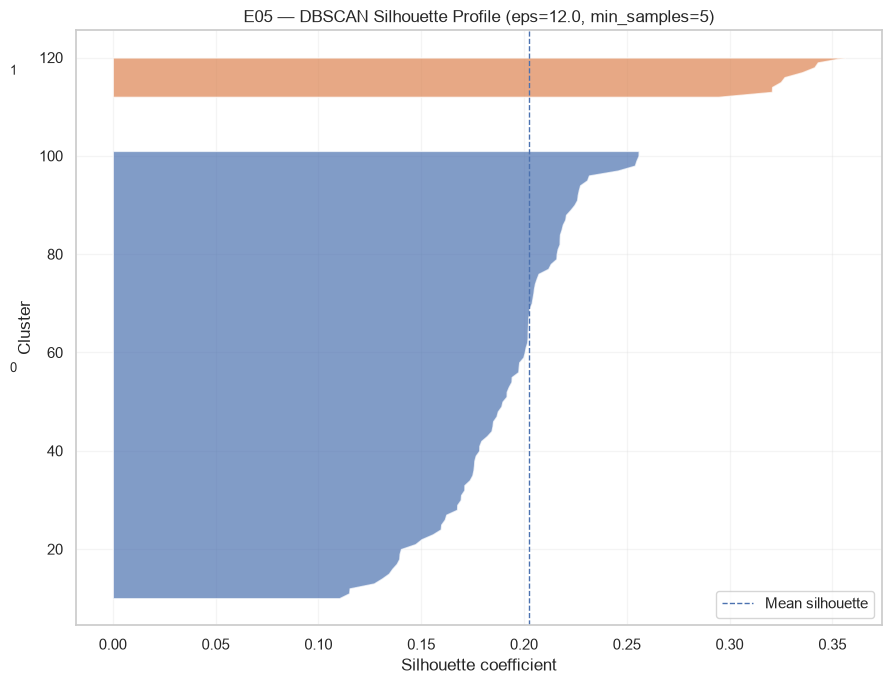

In [43]:
# Plot the strongest valid DBSCAN candidate only when a substantive
# multi-cluster solution exists.
if valid_dbscan_results.empty:
    print(
        "A DBSCAN silhouette profile cannot be calculated because "
        "no valid multi-cluster configuration was produced."
    )
else:
    e05_silhouette = silhouette_profile(
        X_pca,
        e05_labels,
    )

    fig, ax = plt.subplots(figsize=(9, 7))

    plot_silhouette_profile(
        e05_silhouette,
        ax=ax,
        title=(
            "E05 — DBSCAN Silhouette Profile "
            f"(eps={dbscan_eps_candidate:.1f}, "
            f"min_samples={dbscan_min_samples_candidate})"
        ),
    )

    fig.tight_layout()
    plt.show()

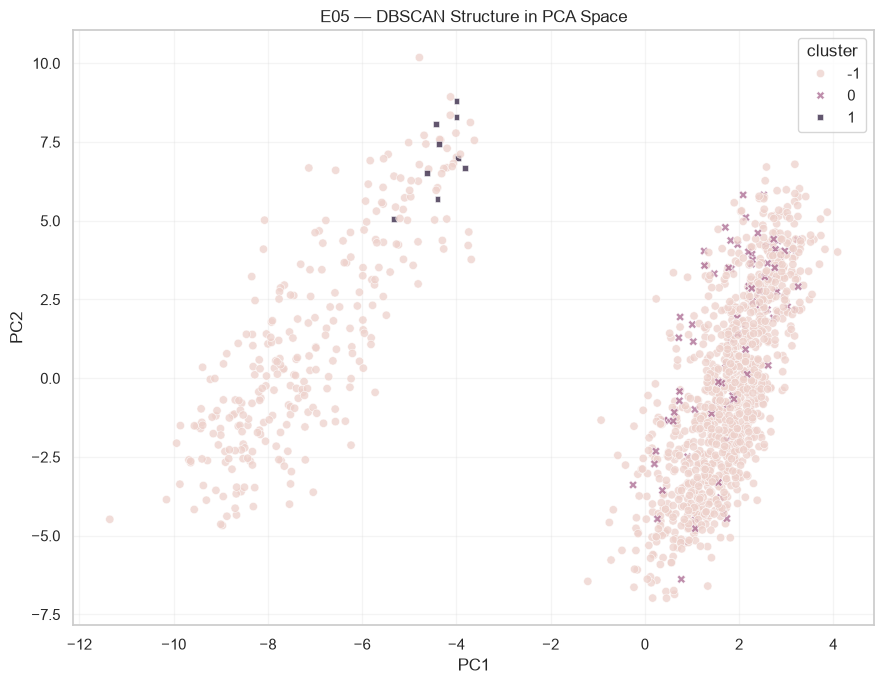

In [44]:
# DBSCAN assignments are displayed in the first two PCA dimensions only for
# visual interpretation. The model itself uses all PCA components.
if valid_dbscan_results.empty:
    print(
        "No multi-cluster DBSCAN projection is available."
    )
else:
    fig, ax = plt.subplots(figsize=(9, 7))

    plot_cluster_projection(
        X_pca.iloc[:, :2],
        e05_labels,
        ax=ax,
        title="E05 — DBSCAN Structure in PCA Space",
        x_label="PC1",
        y_label="PC2",
    )

    fig.tight_layout()
    plt.show()

### 7.8.1 Interpretation of the DBSCAN PCA Projection

The PCA projection shows where the substantive DBSCAN clusters occur within the broader respondent distribution. The figure should be read together with the noise fraction: visible local groups do not imply that the majority of respondents belong to those groups.

# 8. Cross-Model Comparison

## 8.1 Consolidated Evaluation

The selected candidate diagnostics are consolidated here for comparison. The table is not a numerical leaderboard: each metric measures a different property and some are specific to particular model families.

In [45]:
experiment_records = [
    summarize_experiment(
        "E01",
        "K-Means",
        "Selected standardized features",
        {
            "n_clusters": selected_k_candidate,
            "n_init": 20,
            "random_state": RANDOM_STATE,
        },
        e01_evaluation,
    ),
    summarize_experiment(
        "E02",
        "K-Means",
        "PCA",
        {
            "n_clusters": pca_k_candidate,
            "n_init": 20,
            "random_state": RANDOM_STATE,
        },
        e02_evaluation,
    ),
    summarize_experiment(
        "E03",
        "Gaussian Mixture Model",
        "PCA",
        {
            "n_components": gmm_component_candidate,
            "covariance_type": "full",
            "n_init": 10,
            "max_iter": 500,
            "random_state": RANDOM_STATE,
        },
        e03_evaluation,
    ),
    summarize_experiment(
        "E04",
        "Agglomerative Hierarchical",
        "PCA",
        {
            "n_clusters": hierarchical_k_candidate,
            "linkage": "ward",
        },
        e04_evaluation,
    ),
]

if not valid_dbscan_results.empty:
    experiment_records.append(
        summarize_experiment(
            "E05",
            "DBSCAN",
            "PCA",
            {
                "eps": dbscan_eps_candidate,
                "min_samples": dbscan_min_samples_candidate,
                "metric": "euclidean",
            },
            e05_evaluation,
        )
    )

experiment_summary = pd.DataFrame(
    experiment_records
)

display(
    experiment_summary[
        [
            "experiment",
            "model",
            "representation",
            "n_clusters",
            "n_noise",
            "noise_fraction",
            "silhouette",
            "calinski_harabasz",
            "cophenetic_correlation",
            "inertia",
            "bic",
            "aic",
        ]
    ].round(4)
)

,experiment,model,representation,n_clusters,n_noise,noise_fraction,silhouette,calinski_harabasz,cophenetic_correlation,inertia,bic,aic
0,E01,K-Means,Selected standardized features,2,0,0.0000,0.0959,49.1331,NaN,541703.7211,NaN,NaN
1,E02,K-Means,PCA,2,0,0.0000,0.1015,54.7529,NaN,486024.5379,NaN,NaN
2,E03,Gaussian Mixture Model,PCA,5,0,0.0000,0.0186,NaN,NaN,NaN,859349.3612,129012.2282
3,E04,Agglomerative Hierarchical,PCA,2,0,0.0000,0.0840,NaN,0.1618,NaN,NaN,NaN
4,E05,DBSCAN,PCA,2,1332,0.9295,0.2027,NaN,NaN,NaN,NaN,NaN


### 8.1.1 Interpretation of the Cross-Model Evaluation Table

The consolidated table shows the recurring two-cluster pattern for E01, E02, and E04, the BIC-selected five-component GMM, and the conditional DBSCAN result together with its noise fraction. The metrics should be read within their model-specific meaning. In particular, DBSCAN's silhouette is conditional on excluding noise, while GMM BIC/AIC and K-Means inertia are not directly comparable to silhouette.

## 8.2 Common PCA-Space Comparison

The selected assignments are visualised in the same PC1/PC2 coordinate system to support a direct structural comparison. The figure is descriptive only because the underlying models were fitted in higher-dimensional spaces.

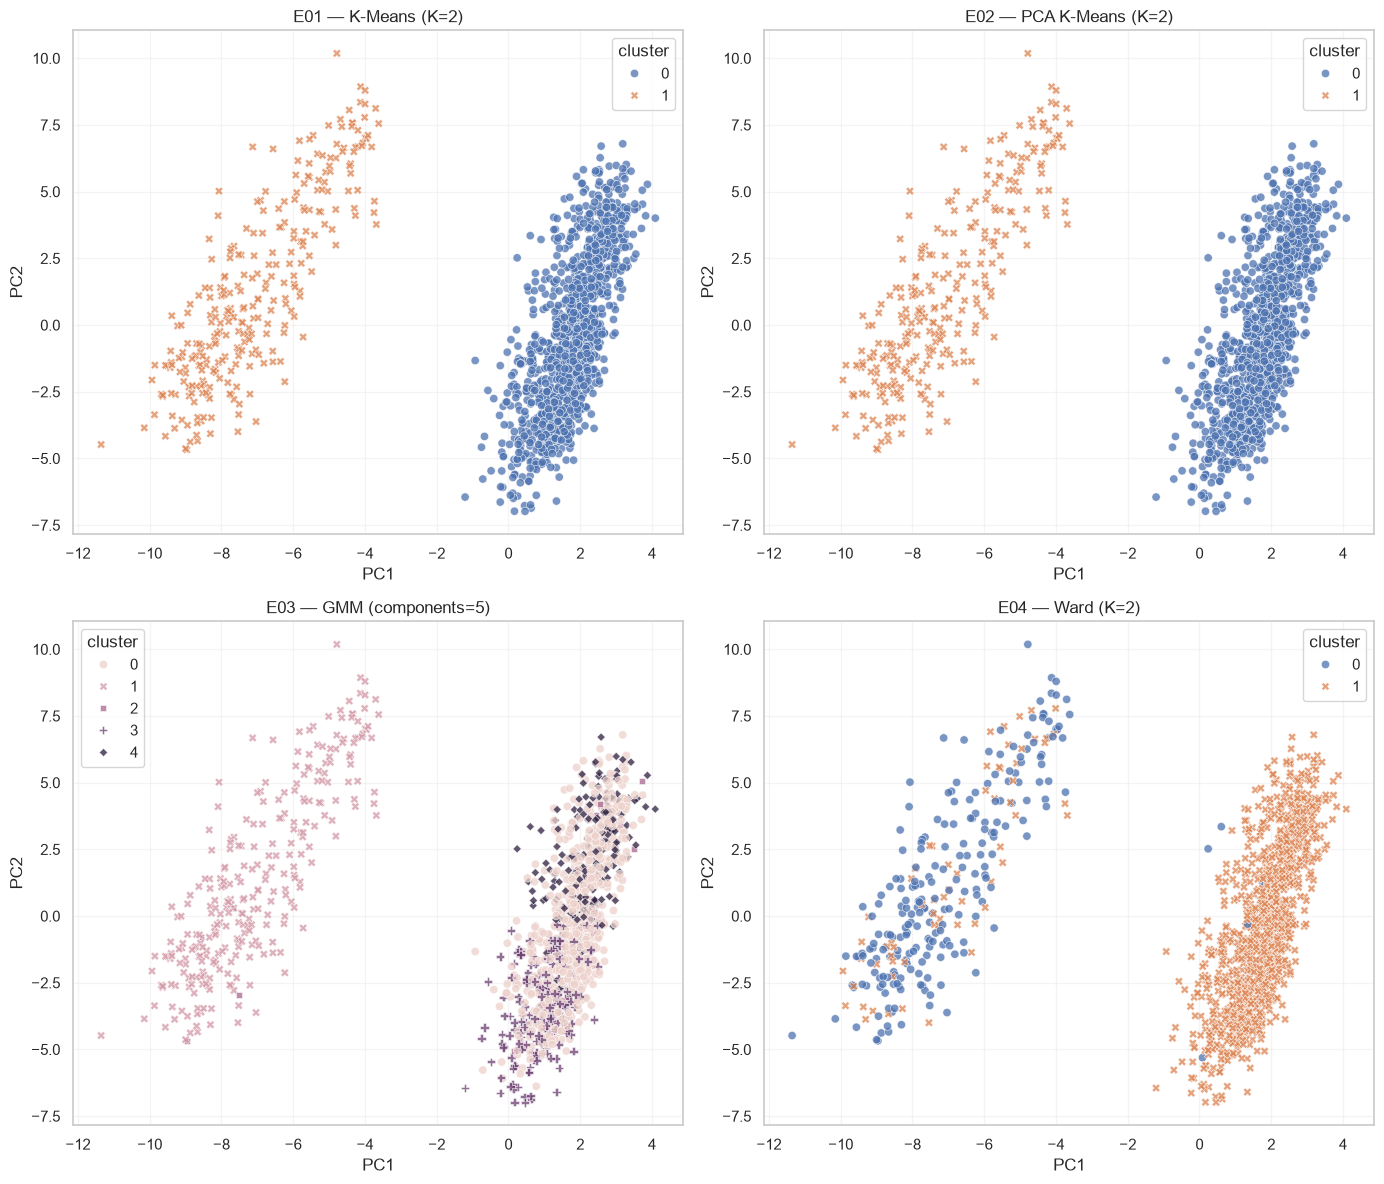

In [46]:
# Compare the candidate assignments in a common PC1/PC2 visualization.
fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 12),
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e01_labels,
    ax=axes[0, 0],
    title=f"E01 — K-Means (K={selected_k_candidate})",
    x_label="PC1",
    y_label="PC2",
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e02_labels,
    ax=axes[0, 1],
    title=f"E02 — PCA K-Means (K={pca_k_candidate})",
    x_label="PC1",
    y_label="PC2",
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e03_labels,
    ax=axes[1, 0],
    title=(
        f"E03 — GMM "
        f"(components={gmm_component_candidate})"
    ),
    x_label="PC1",
    y_label="PC2",
)

plot_cluster_projection(
    X_pca.iloc[:, :2],
    e04_labels,
    ax=axes[1, 1],
    title=(
        f"E04 — Ward "
        f"(K={hierarchical_k_candidate})"
    ),
    x_label="PC1",
    y_label="PC2",
)

fig.tight_layout()
plt.show()

### 8.2.1 Interpretation of the Common PCA Comparison Figure

The common PC1/PC2 projection shows a recurring broad separation between two regions for E01 and E02, a related but differently assigned partition for Ward, and several overlapping GMM components. The visualisation supports the existence of broad structure while also showing overlap. Because only the first two principal components are displayed, it is not a complete representation of the fitted clustering spaces.

## 8.3 Cross-Model Synthesis

The most consistent structural finding is a broad two-group pattern. E01 K-Means, E02 PCA K-Means, and E04 Ward all identify K=2 as the strongest tested partition. The K-Means solutions produce approximately the same 80/20 population split, while Ward produces an approximately 84/16 split.

The separation remains weak. The silhouette values are low, and the observation-level profiles contain observations close to zero or below zero. The recurring two-group pattern should therefore be treated as detectable broad structure rather than two sharply separated respondent populations.

GMM provides a different conclusion under model-fit criteria: BIC favours five components, while silhouette favours two components. The selected five-component solution also behaves almost like hard assignment because maximum membership probabilities are effectively one. This disagreement between statistical fit and geometric separation is an important result rather than a contradiction.

DBSCAN identifies local dense regions, but its strongest conditional silhouette is accompanied by a very large noise fraction. The K-distance experiment makes the parameter search more data-informed, yet the resulting density structure remains too sensitive and incomplete for a convincing population-wide segmentation.

# 9. Conclusion and Handoff to Notebook 05

## 9.1 Analytical conclusion

The clustering experiments show detectable structure but generally weak separation. The recurring two-group pattern is the principal candidate for substantive profiling, while the GMM and DBSCAN results remain important comparison evidence.

## 9.2 Handoff to Notebook 05

Notebook 05 should return to the original survey variables and determine whether the mathematical partitions correspond to meaningful differences in workplace characteristics, mental-health-related responses, and reported support. It should not repeat the clustering diagnostics.

Carry forward E01 K-Means K=2, E02 PCA K-Means K=2, E03 GMM five components, and E04 Ward K=2. Retain E05 DBSCAN as a density diagnostic and only profile it further if its final parameterisation provides a substantively useful subset.

## 9.3 Final decision boundary

No final clustering model is selected in Notebook 04. The final choice depends on substantive interpretability and evidence from the original survey variables.